In [13]:
import pandas as pd
import numpy as np

In [14]:
df_rank_sum_merged = pd.read_excel('/data/project/yeonu/arpa_h/MSS_specific_with_median_expression.xlsx')
print(df_rank_sum_merged.shape)
print(df_rank_sum_merged.head())

(95, 22)
       gene  rank_sum_in_myeloid  rank_sum_in_eptheilal  rank_sum_in_plasma  \
0      C1QA                    5                  28476               28476   
1      C1QB                    5                  28476               28476   
2  HLA-DPB1                    5                  28476               28476   
3      CD63                    5                   6741                1922   
4     NAMPT                    5                  28476               28476   

   rank_sum_in_neutrophil  rank_sum_in_stromal  rank_sum_in_b_cell  \
0                   28476                28476               28476   
1                   28476                28476               28476   
2                   28476                11065                1373   
3                     758                15605               28476   
4                     497                17266               28476   

   rank_sum_in_mast  myeloid/MSI_high  myeloid/MSS_high  ...  plasma/MSI_high  \
0             

In [15]:
df_rank_sum_merged

,gene,rank_sum_in_myeloid,rank_sum_in_eptheilal,rank_sum_in_plasma,rank_sum_in_neutrophil,rank_sum_in_stromal,rank_sum_in_b_cell,rank_sum_in_mast,myeloid/MSI_high,myeloid/MSS_high,...,plasma/MSI_high,plasma/MSS_high,neutrophil/MSI_high,neutrophil/MSS_high,stromal/MSI_high,stromal/MSS_high,B_cell/MSI_high,B_cell/MSS_high,mast/MSI_high,mast/MSS_high
0,C1QA,5,28476,28476,28476,28476,28476,28476,0.000000,1.285883,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C1QB,5,28476,28476,28476,28476,28476,28476,0.000000,1.233300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HLA-DPB1,5,28476,28476,28476,11065,1373,28476,0.726990,1.811807,...,NaN,NaN,NaN,NaN,0.000000,0.000000,2.109573,1.810495,NaN,NaN
3,CD63,5,6741,1922,758,15605,28476,1924,0.419511,1.423286,...,0.63172,0.0,0.000000,0.000000,1.571331,1.542878,NaN,NaN,1.51117,1.783497
4,NAMPT,5,28476,28476,497,17266,28476,4642,0.000000,0.971333,...,NaN,NaN,3.166568,2.688861,0.000000,0.144002,NaN,NaN,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,TFRC,5,8379,28476,28476,28476,28476,28476,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91,THBS1,5,5906,28476,28476,7230,28476,28476,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.486038,0.297585,NaN,NaN,NaN,NaN
92,VEGFA,5,3825,28476,28476,28476,28476,590,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,0.000000
93,VSIG4,5,28476,28476,28476,28476,28476,28476,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# ▶ Load expression matrix
expr_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/filtered_count_matrix/filtered_myeloid_count.csv"
expr_df = pd.read_csv(expr_path, index_col=0)

In [17]:
expr_df

,Che_2021-SRR14710630-AAAGATGAGAGGTAGA,Che_2021-SRR14710630-AAAGCAAGTTCAGCGC,Che_2021-SRR14710630-AACCATGTCGTACCGG,Che_2021-SRR14710630-AACGTTGGTCTCCATC,Che_2021-SRR14710630-AAGACCTAGCCCAGCT,Che_2021-SRR14710630-AAGACCTGTGTGAAAT,Che_2021-SRR14710630-AAGCCGCAGTAGCCGA,Che_2021-SRR14710630-ACACCGGAGGTAGCTG,Che_2021-SRR14710630-ACAGCTACATGGAATA,Che_2021-SRR14710630-ACGATACGTCAGAGGT,...,Zheng_2022-GSM4904246-TGGCCAGCAAGTCTAC,Zheng_2022-GSM4904246-TGGGAAGAGCTGTCTA,Zheng_2022-GSM4904246-TGTATTCCACGAAACG,Zheng_2022-GSM4904246-TTAGTTCCATCGATGT,Zheng_2022-GSM4904246-TTAGTTCTCCACGCAG,Zheng_2022-GSM4904246-TTCGAAGGTTCGCTAA,Zheng_2022-GSM4904246-TTCTCAACAAGTAATG,Zheng_2022-GSM4904246-TTGAACGTCATGTCTT,Zheng_2022-GSM4904246-TTTACTGTCAGAAATG,Zheng_2022-GSM4904246-TTTGGTTGTCCAGTAT
ISG15,0.958678,1.888139,0.000000,0.000000,0.000000,0.000000,0.516216,0.488505,1.886642,0.748321,...,0.000000,0.000000,0.363373,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
SDF4,0.278880,0.000000,0.000000,0.000000,0.224762,0.338045,0.291055,0.350599,0.382832,0.442584,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.595361,0.000000,0.000000,0.000000
AURKAIP1,0.496706,0.876204,0.392562,0.386227,0.697187,0.338045,0.291055,0.350599,0.659002,0.442584,...,0.000000,0.000000,0.000000,0.498737,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
MRPL20,0.278880,0.876204,0.000000,0.000000,0.563080,0.338045,0.516216,0.350599,0.382832,0.000000,...,0.810712,0.000000,0.629326,0.000000,0.582764,0.000000,0.000000,0.000000,0.444537,0.000000
SSU72,0.278880,0.876204,0.000000,0.386227,0.408160,0.338045,0.291055,0.190586,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.498737,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-ND4L,0.278880,0.000000,0.000000,0.386227,0.224762,0.338045,0.516216,0.000000,0.382832,0.442584,...,1.252482,0.975610,0.363373,1.277193,0.000000,0.950386,0.000000,0.579918,0.444537,0.000000
MT-ND4,2.303203,2.380690,2.267356,2.862180,2.382222,2.884386,2.577346,1.196812,2.675976,2.625007,...,2.602325,3.250056,3.112202,2.723009,2.912437,3.073951,2.297627,2.906333,2.997335,2.721678
MT-ND5,1.512518,1.335930,1.072637,1.964092,1.327676,1.613837,1.551007,0.609676,1.554232,1.171521,...,0.810712,1.784794,1.012579,1.585112,1.600379,1.428734,0.965984,1.871993,0.751197,1.020913
MT-ND6,0.278880,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.444537,0.000000


In [31]:
# ▶ Load metadata
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_myeloid_consensus.csv"
meta_df = pd.read_csv(meta_path)

In [32]:
# 그릴 유전자 리스트 (head 20)
gene_list = df_rank_sum_merged.head(20)['gene'].tolist()

# 발현 행렬에서 상위 유전자만 추출하고 전치 (세포×유전자)
expr = expr_df.loc[gene_list].T

In [33]:
expr

,C1QA,C1QB,HLA-DPB1,CD63,NAMPT,GLUL,HLA-DQA1,PRDX1,C1QC,RPS29,LITAF,IER3,TNFAIP3,CXCL8,MARCKS,CTSB,GADD45B,CD163,CCL3,RPS20
Che_2021-SRR14710630-AAAGATGAGAGGTAGA,2.674788,2.893002,2.048291,2.165571,1.359653,1.580995,1.645083,1.512518,2.365511,1.645083,1.273460,1.074967,1.359653,1.645083,0.827065,2.910668,1.179130,0.827065,2.452248,1.439004
Che_2021-SRR14710630-AAAGCAAGTTCAGCGC,0.000000,0.000000,1.888139,1.888139,1.335930,1.335930,1.335930,1.335930,0.000000,1.888139,1.335930,1.335930,1.335930,2.241836,0.876204,2.080545,0.876204,0.876204,2.880388,1.888139
Che_2021-SRR14710630-AACCATGTCGTACCGG,0.000000,0.000000,3.473518,0.392562,0.392562,0.000000,2.853371,0.392562,0.000000,2.671493,1.357024,0.000000,0.000000,0.000000,0.000000,0.000000,1.578185,0.000000,0.000000,2.267356
Che_2021-SRR14710630-AACGTTGGTCTCCATC,3.469279,3.483852,3.079264,2.088311,1.656848,1.458598,3.034932,1.562628,2.939896,1.342475,0.664149,0.000000,0.664149,2.145076,0.881390,2.748165,1.211074,0.881390,2.939896,1.458598
Che_2021-SRR14710630-AAGACCTAGCCCAGCT,2.382222,2.405229,2.715579,1.103995,1.103995,1.103995,2.382222,1.258530,1.952826,2.204396,1.103995,1.564516,1.258530,2.764394,0.408160,1.711351,1.184245,0.563080,1.916416,2.117303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zheng_2022-GSM4904246-TTCGAAGGTTCGCTAA,2.825363,2.616932,1.994268,0.950386,1.750958,0.950386,0.950386,0.000000,2.493779,2.353301,0.000000,1.994268,0.000000,2.353301,1.994268,1.428734,0.950386,0.000000,0.000000,1.994268
Zheng_2022-GSM4904246-TTCTCAACAAGTAATG,0.000000,0.000000,1.235778,0.000000,1.623030,0.000000,0.000000,0.000000,0.000000,2.297627,0.000000,1.235778,0.000000,0.000000,0.595361,0.965984,0.595361,0.000000,0.000000,1.448034
Zheng_2022-GSM4904246-TTGAACGTCATGTCTT,2.717739,1.871993,2.717739,1.421556,0.579918,0.944599,2.088528,0.944599,0.579918,2.344753,0.000000,0.944599,0.944599,0.579918,0.579918,0.944599,0.000000,0.579918,0.000000,1.421556
Zheng_2022-GSM4904246-TTTACTGTCAGAAATG,0.000000,0.000000,1.472152,0.000000,0.751197,0.444537,0.751197,0.000000,0.000000,2.997335,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.404764


In [34]:
gene_list = df_rank_sum_merged.head(20)['gene'].tolist()

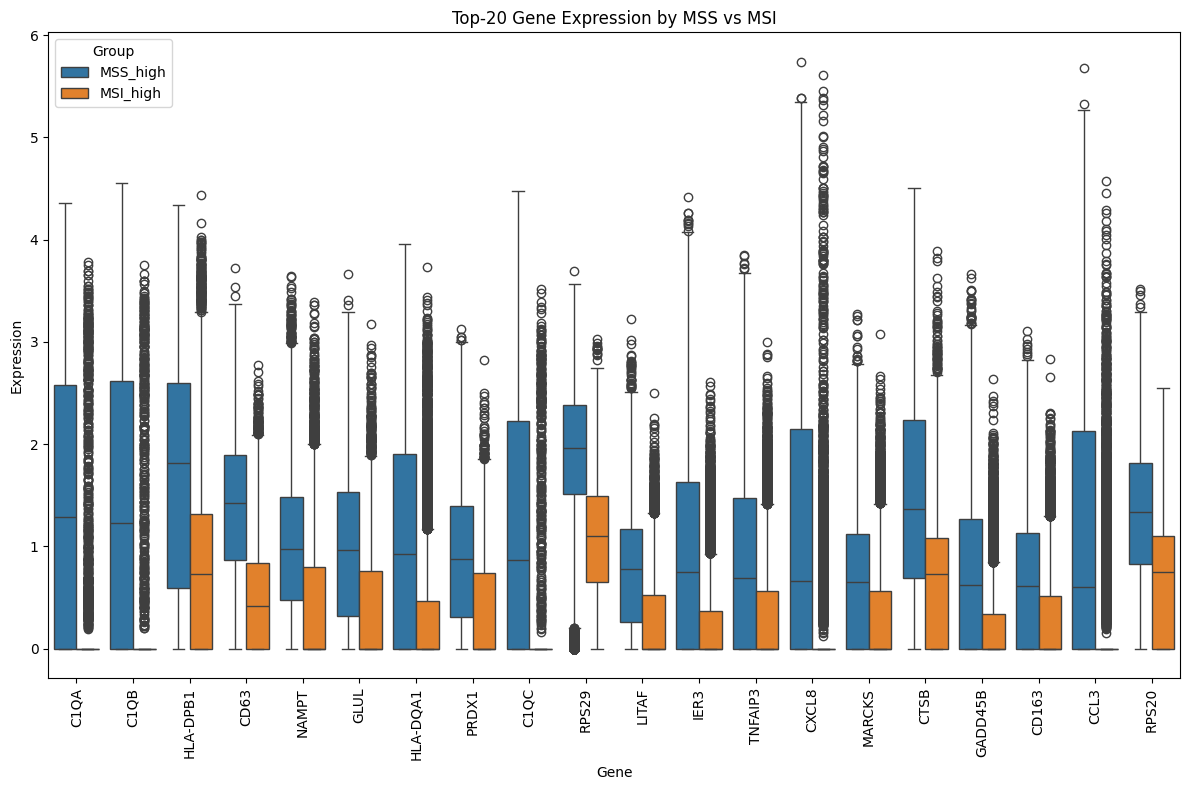

In [35]:
# 필요한 라이브러리 임포트
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Prepare expression + metadata for the top‑20 genes
expr = expr_df.loc[gene_list].T  # transpose so cells×genes
expr = expr.merge(meta_df[['cell_name','Group']], left_index=True, right_on='cell_name')

# Boxplot of expression for each gene split by MSS vs MSI
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=expr.melt(id_vars='Group', value_vars=gene_list, var_name='Gene', value_name='Expression'),
    x='Gene', y='Expression', hue='Group'
)
plt.xticks(rotation=90)
plt.title('Top‑20 Gene Expression by MSS vs MSI')
plt.tight_layout()
plt.show()

In [36]:
import pandas as pd

# 1) long 포맷으로 변환
expr_long = expr.melt(
    id_vars=['cell_name','Group'],
    value_vars=gene_list,
    var_name='Gene',
    value_name='Expression'
)

# 2) Gene×Group별 평균 발현 계산
group_summary = (
    expr_long
    .groupby(['Gene','Group'])['Expression']
    .mean()
    .unstack('Group')
)

# 3) Gene을 인덱스로, 원하는 순서인 gene_list 로 재색인
group_summary = group_summary.reindex(gene_list)

# 4) 인덱스를 다시 컬럼으로
group_summary = group_summary.reset_index().rename(columns={'index':'Gene'})

# 5) 컬럼 순서 정리 (필요 시)
group_summary = group_summary[['Gene','MSI_high','MSS_high']]

# 6) 결과 확인
print(group_summary)


Group      Gene  MSI_high  MSS_high
0          C1QA  0.039504  1.318994
1          C1QB  0.032490  1.327036
2      HLA-DPB1  0.792377  1.640593
3          CD63  0.461927  1.342238
4         NAMPT  0.435039  0.995564
5          GLUL  0.402623  0.978981
6      HLA-DQA1  0.293176  1.049963
7         PRDX1  0.389204  0.880590
8          C1QC  0.026285  1.123528
9         RPS29  1.030866  1.881892
10        LITAF  0.259391  0.766922
11         IER3  0.213225  0.957483
12      TNFAIP3  0.293884  0.840376
13        CXCL8  0.111728  1.126563
14       MARCKS  0.289048  0.684366
15         CTSB  0.684327  1.450778
16      GADD45B  0.201194  0.745357
17        CD163  0.258888  0.687127
18         CCL3  0.129563  1.115618
19        RPS20  0.693275  1.293366
